# Notebook to compare current versus previous implementation of thermo uncertainty

## Load libraries, database, some useful functions

In [1]:
import numpy as np
import scipy.optimize
import rmgpy.tools.uncertainty
import rmgpy.data.rmg
import rmgpy.chemkin
import matplotlib.pyplot as plt
%matplotlib inline

import importlib
importlib.reload(rmgpy.tools.uncertainty)

<module 'rmgpy.tools.uncertainty' from '/home/moon/rmg/RMG-Py/rmgpy/tools/uncertainty.py'>

In [2]:
thermo_engine = rmgpy.tools.uncertainty.ThermoParameterUncertainty()

In [3]:
# Load a database with just group additivity for thermo
database = rmgpy.data.rmg.RMGDatabase()
database.load(
    path=rmgpy.settings['database.directory'],
    thermo_libraries=[],
    transport_libraries=[],
    reaction_libraries=[],
    seed_mechanisms=[],
    kinetics_families='none',
    kinetics_depositories=[],
    depository=False,
)

In [4]:
def get_n_groups(entry):
    groups = 0
    if 'GAV' not in entry.keys():
        return groups
    for key in entry['GAV'].keys():
        for group_entry in entry['GAV'][key]:
            groups += group_entry[1]
    return groups

In [5]:
def get_previous_implementation_uncertainty(species):
    if species.thermo is None:
        species.thermo = database.thermo.get_thermo_data(species)
    source = database.thermo.extract_source_from_comments(species)
    return 1.5 + 0.1 * get_n_groups(source)

# This should work the same as thermo_engine.get_uncertainty_value() for simple gas-phase thermo
# var_GAV = 1.5 ** 2.0
# var_lib = 1.5 ** 2.0
# var_group = 0.316 ** 2.0
# def get_quadrature_implementation_uncertainty(species):
#     if species.thermo is None:
#         species.thermo = database.thermo.get_thermo_data(species)
#     source = database.thermo.extract_source_from_comments(species)

#     varG = 0
#     if 'Library' in source:
#         varG += var_lib

#     if 'GAV' in source:
#         varG += var_GAV
        
#         for group_type, group_entries in source['GAV'].items():
#             for group, count in group_entries:
#                 varG += var_group * (count ** 2.0)
#     return np.sqrt(varG)

# Pick a species to compare uncertainty estimates for

## The previous implementation depends only on the total number of groups
## While the quadrature one depends the number of groups and how often a group repeats

In [6]:
sp1 = rmgpy.species.Species(smiles='CCCC')
display(sp1)
print()
sp1.thermo = database.thermo.get_thermo_data(sp1)
source1 = database.thermo.extract_source_from_comments(sp1)
N = get_n_groups(source1)

print('Uncertainty Sources:')
display(source1)
print()
print(f'{sp1} has {N} total groups')
print()
print(f'Original uncertainty:\t{get_previous_implementation_uncertainty(sp1):.4f} kcal/mol')
print(f'\t\t\t1.5 + {N}*0.1 kcal/mol')
print()
print(f'Quadrature uncertainty:\t{thermo_engine.get_uncertainty_value(source1):.4f} kcal/mol')

group_string = ''
for group_type, group_entries in source1['GAV'].items():
    for group, count in group_entries:
        group_string += f' + {count}^2*{thermo_engine.dG_group}^2'
group_string = group_string[3:]


# print(f'\t\t\tsqrt(1.5^2 + {group_string}) kcal/mol')  # prettier version
group_string = group_string.replace('^', '**')
print(f'\t\t\tnp.sqrt(1.5**2 + {group_string}) kcal/mol')  # copyable in code


Uncertainty Sources:


{'GAV': {'group': [(<Entry index=953 label="Cs-CsCsHH">, 2),
   (<Entry index=921 label="Cs-CsHHH">, 2)]}}


CCCC has 4 total groups

Original uncertainty:	1.9000 kcal/mol
			1.5 + 4*0.1 kcal/mol

Quadrature uncertainty:	2.2354 kcal/mol
			np.sqrt(1.5**2 + 2**2*0.586**2 + 2**2*0.586**2) kcal/mol


## Repeating groups yield higher uncertainties than unique groups

In [7]:
sp2 = rmgpy.species.Species(smiles='CCCCCCCCCC')
display(sp2)
print()
sp2.thermo = database.thermo.get_thermo_data(sp2)
source2 = database.thermo.extract_source_from_comments(sp2)
N = get_n_groups(source2)

print('Uncertainty Sources:')
display(source2)
print()
print(f'{sp2} has {N} total groups')
print()
print(f'Original uncertainty:\t{get_previous_implementation_uncertainty(sp2):.4f} kcal/mol')
print(f'\t\t\t1.5 + {N}*0.1 kcal/mol')
print()
print(f'Quadrature uncertainty:\t{thermo_engine.get_uncertainty_value(source2):.4f} kcal/mol')

group_string = ''
for group_type, group_entries in source2['GAV'].items():
    for group, count in group_entries:
        group_string += f' + {count}^2*{thermo_engine.dG_group}^2'
group_string = group_string[3:]


# print(f'\t\t\tsqrt(1.5^2 + {group_string}) kcal/mol')  # prettier version
group_string = group_string.replace('^', '**')
print(f'\t\t\tnp.sqrt(1.5**2 + {group_string}) kcal/mol')  # copyable in code


Uncertainty Sources:


{'GAV': {'group': [(<Entry index=953 label="Cs-CsCsHH">, 8),
   (<Entry index=921 label="Cs-CsHHH">, 2)]}}


CCCCCCCCCC has 10 total groups

Original uncertainty:	2.5000 kcal/mol
			1.5 + 10*0.1 kcal/mol

Quadrature uncertainty:	5.0597 kcal/mol
			np.sqrt(1.5**2 + 8**2*0.586**2 + 2**2*0.586**2) kcal/mol


# Load a set of species that have good library values to compare against

In [8]:
# double check against my own saved data
original_uncertainty = np.load('thermo_chemkin_files/original_GAV_input_uncertainties.npy')
quadrature_uncertainty = np.load('thermo_chemkin_files/quadrature_GAV_input_uncertainties.npy')
GAV_chemkin = 'thermo_chemkin_files/GAV.inp'
GAV_spec_dict = 'thermo_chemkin_files/GAV_species_dictionary.txt'
species_list, _ = rmgpy.chemkin.load_chemkin_file(GAV_chemkin, GAV_spec_dict)


for i in range(len(species_list)):
    # some of these fail because of this bug: https://github.com/ReactionMechanismGenerator/RMG-Py/issues/2926
    # Just use get_previous_implementation_uncertainty
    # assert np.isclose(original_uncertainty[i], get_previous_implementation_uncertainty(species_list[i])), i 
    
    # assert np.isclose(quadrature_uncertainty[i], get_quadrature_implementation_uncertainty(species_list[i])), i
    source = database.thermo.extract_source_from_comments(species_list[i])
    assert np.isclose(quadrature_uncertainty[i], thermo_engine.get_uncertainty_value(source)), i
original_uncertainty = [get_previous_implementation_uncertainty(sp) for sp in species_list]

# We can plot uncertainties as a function of the number of groups

### Quadrature gives a range that depends on how many groups get repeated

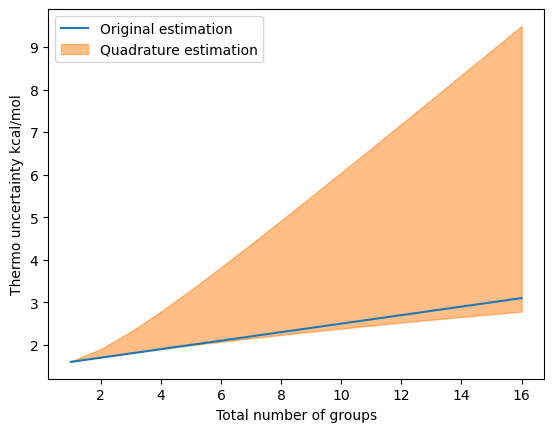

In [9]:
n = np.arange(1, 17)
original_uncertainty = 1.5 + 0.1 * n

quadrature_min = np.sqrt(thermo_engine.dG_GAV**2.0 + n * ((1.0 ** 2.0) * (thermo_engine.dG_group ** 2.0)))  # no group gets repeated
quadrature_max = np.sqrt(thermo_engine.dG_GAV**2.0 + (n ** 2.0) * (thermo_engine.dG_group ** 2.0))  # every group is the same

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.plot(n, original_uncertainty, label='Original estimation', color=colors[0])
plt.fill_between(n, quadrature_min, quadrature_max, label='Quadrature estimation', alpha=0.5, color=colors[1])
plt.xlabel('Total number of groups')
plt.ylabel('Thermo uncertainty kcal/mol')
plt.legend()

# We can superimpose the species uncertainty estimates on the plot

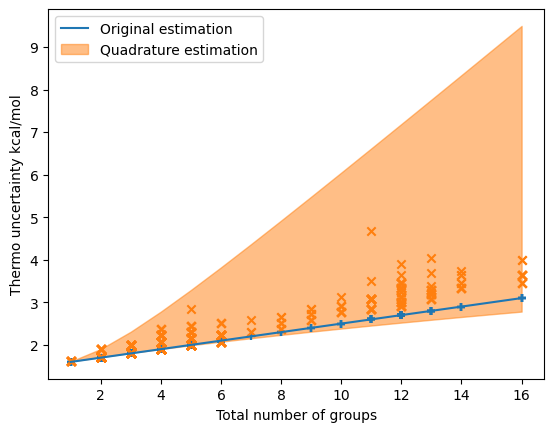

In [10]:
n_groups = np.zeros(len(species_list))
original_calcs = np.zeros(len(species_list))
quadrature_calcs = np.zeros(len(species_list))
for i in range(len(species_list)):
    source = database.thermo.extract_source_from_comments(species_list[i])
    n_groups[i] = get_n_groups(source)
    original_calcs[i] = get_previous_implementation_uncertainty(species_list[i])
    quadrature_calcs[i] = thermo_engine.get_uncertainty_value(source)


n = np.arange(1, 17)
original_uncertainty = 1.5 + 0.1 * n

quadrature_min = np.sqrt(thermo_engine.dG_GAV**2.0 + n * ((1.0 ** 2.0) * (thermo_engine.dG_group ** 2.0)))  # no group gets repeated
quadrature_max = np.sqrt(thermo_engine.dG_GAV**2.0 + (n ** 2.0) * (thermo_engine.dG_group ** 2.0))  # every group is the same


colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.plot(n, original_uncertainty, label='Original estimation', color=colors[0])
plt.fill_between(n, quadrature_min, quadrature_max, label='Quadrature estimation', alpha=0.5, color=colors[1])

plt.scatter(n_groups, original_calcs, color=colors[0], marker='+')
plt.scatter(n_groups, quadrature_calcs, color=colors[1], marker='x')

plt.xlabel('Total number of groups')
plt.ylabel('Thermo uncertainty kcal/mol')
plt.legend()


# We can play with the values in the thermo engine to adjust the quadrature calculation

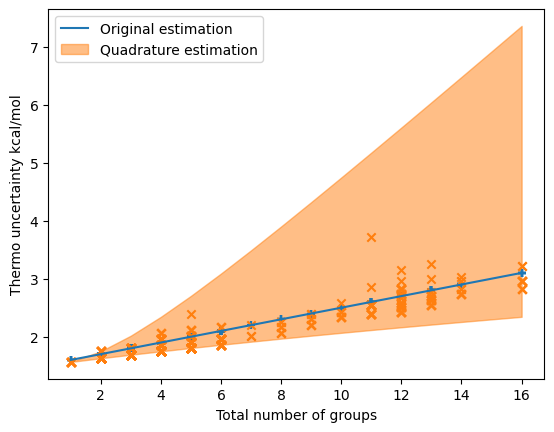

In [11]:
thermo_engine = rmgpy.tools.uncertainty.ThermoParameterUncertainty(
    dG_library=1.5,
    dG_GAV=1.5,
    dG_group=0.45, # <------------ try changing this from its default of 0.6 kcal/mol
)


n_groups = np.zeros(len(species_list))
original_calcs = np.zeros(len(species_list))
quadrature_calcs = np.zeros(len(species_list))
for i in range(len(species_list)):
    source = database.thermo.extract_source_from_comments(species_list[i])
    n_groups[i] = get_n_groups(source)
    original_calcs[i] = get_previous_implementation_uncertainty(species_list[i])
    quadrature_calcs[i] = thermo_engine.get_uncertainty_value(source)


n = np.arange(1, 17)
original_uncertainty = 1.5 + 0.1 * n

quadrature_min = np.sqrt(thermo_engine.dG_GAV**2.0 + n * ((1.0 ** 2.0) * (thermo_engine.dG_group ** 2.0)))  # no group gets repeated
quadrature_max = np.sqrt(thermo_engine.dG_GAV**2.0 + (n ** 2.0) * (thermo_engine.dG_group ** 2.0))  # every group is the same


colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.plot(n, original_uncertainty, label='Original estimation', color=colors[0])
plt.fill_between(n, quadrature_min, quadrature_max, label='Quadrature estimation', alpha=0.5, color=colors[1])

plt.scatter(n_groups, original_calcs, color=colors[0], marker='+')
plt.scatter(n_groups, quadrature_calcs, color=colors[1], marker='x')

plt.xlabel('Total number of groups')
plt.ylabel('Thermo uncertainty kcal/mol')
plt.legend()


# How do we decide what to make dG_group?

## Look at a representative dataset (this has 564 species) of the actual GAV errors

/home/moon/miniforge3/envs/rmg_env/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


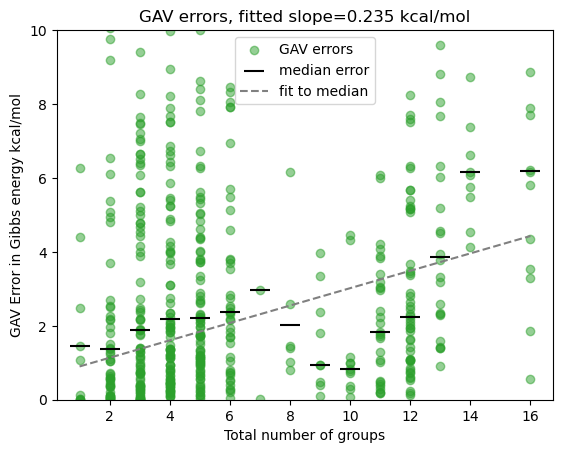

In [12]:
# compute GAV error in Gibbs energy at 1000.0K
T_ref = 1000.0
ref_species_list, _ = rmgpy.chemkin.load_chemkin_file('thermo_chemkin_files/combined.inp', 'thermo_chemkin_files/combined_species_dictionary.txt')
GAV_error = np.zeros(len(species_list))
for i in range(len(species_list)):
    GAV_error[i] = np.abs(species_list[i].get_free_energy(T_ref) - ref_species_list[i].get_free_energy(T_ref)) / 4184.0

# Plot the GAV error
plt.scatter(n_groups, GAV_error, color=colors[2], alpha=0.5, label='GAV errors')


# Fit a line through the median value for each set falling under a given number of heavy atoms
# too many outliers for mean to work here
medians = np.zeros(int(max(n_groups))) + np.nan
xs = np.arange(len(medians)) + 1
for j in range(len(medians)):
    subset = [GAV_error[i] for i in range(len(ref_species_list)) if n_groups[i] == xs[j]]
    medians[j] = np.nanmedian(np.abs(subset))


plt.scatter(xs, medians, marker='_', color='black', s=200, label='median error')

xs = xs[~np.isnan(medians)]
medians = medians[~np.isnan(medians)]
m, b = np.polyfit(xs, medians, deg=1)
plt.plot(xs, b + m * xs, color='grey', linestyle='dashed', label='fit to median')

plt.title(f'GAV errors, fitted slope={m:0.3f} kcal/mol')

plt.xlabel('Total number of groups')
plt.ylabel('GAV Error in Gibbs energy kcal/mol')
plt.ylim([0, 10.0])
plt.legend()


# Now superimpose our quadrature estimation on top of the same plot

### dG_group = 0.316 is probably too low

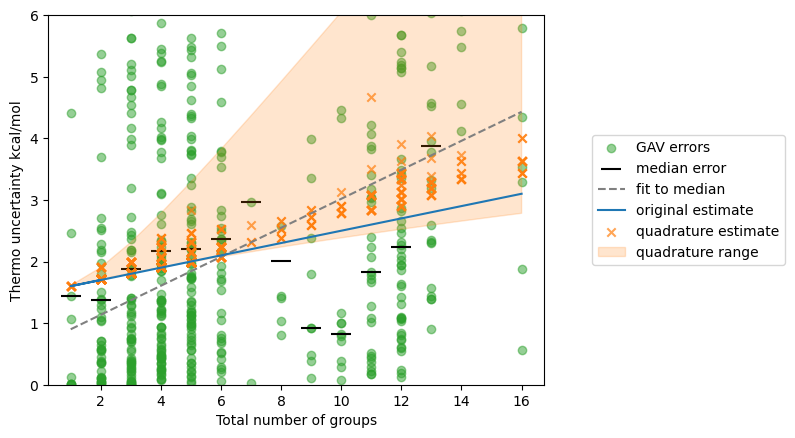

In [13]:
thermo_engine = rmgpy.tools.uncertainty.ThermoParameterUncertainty(dG_group=0.586)  # <--------------- change this
# 0.316 kcal/mol (sqrt(0.1, the previous default value)) is probably too low
# 1.0 kcal/mol is obviously too high
# 0.586 kcal/mol is the "best fit" to the median best fit line
# 0.476 is the "best fit" to the previous estimation method


quadrature_calcs = np.zeros(len(species_list))
for i in range(len(species_list)):
    source = database.thermo.extract_source_from_comments(species_list[i])
    n_groups[i] = get_n_groups(source)
    original_calcs[i] = get_previous_implementation_uncertainty(species_list[i])
    quadrature_calcs[i] = thermo_engine.get_uncertainty_value(source)
plt.scatter(n_groups, GAV_error, color=colors[2], alpha=0.5, label='GAV errors')
plt.scatter(xs, medians, marker='_', color='black', s=200, label='median error')
plt.plot(xs, b + m * xs, color='grey', linestyle='dashed', label='fit to median')

plt.plot(n_groups, original_calcs, color=colors[0], label='original estimate')
plt.scatter(n_groups, quadrature_calcs, color=colors[1], marker='x', label='quadrature estimate', alpha=0.7)

quadrature_min = np.sqrt(thermo_engine.dG_GAV**2.0 + n * ((1.0 ** 2.0) * (thermo_engine.dG_group ** 2.0)))  # no group gets repeated
quadrature_max = np.sqrt(thermo_engine.dG_GAV**2.0 + (n ** 2.0) * (thermo_engine.dG_group ** 2.0))  # every group is the same
plt.fill_between(n, quadrature_min, quadrature_max, label='quadrature range', alpha=0.2, color=colors[1])


plt.xlabel('Total number of groups')
plt.ylabel('Thermo uncertainty kcal/mol')
plt.ylim([0, 6.0])
plt.legend(loc='right', bbox_to_anchor=(1.5, 0.5))

# We can optimize dG_group to match the fit to median (or previous estimate)

In [14]:
def my_function(xs, dG_group):
    thermo_engine = rmgpy.tools.uncertainty.ThermoParameterUncertainty(dG_group=dG_group)
    quadrature_calcs = np.zeros(len(species_list))
    for i in range(len(species_list)):
        source = database.thermo.extract_source_from_comments(species_list[i])
        n_groups[i] = get_n_groups(source)
        quadrature_calcs[i] = thermo_engine.get_uncertainty_value(source)
    return quadrature_calcs
    

In [15]:
xdata = n_groups
ydata = b + m * xdata  # <----------- use this to fit to median best fit line of GAV error
# ydata = original_calcs  # <----------- use this to fit to previous estimation method

In [16]:
optimized_dG_group, var = scipy.optimize.curve_fit(my_function, xdata, ydata, p0=1.0)

In [17]:
optimized_dG_group

array([0.58611621])

# dG_group = 0.586 kcal/mol results in a good fit to the median GAV error
## The uncertainties tend to be a little larger than the previous estimation method, but not by much